In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Dataset/df.csv")

In [4]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month
0,1998-12-31 01:00:00,26498.0,1,3,12
1,1998-12-31 02:00:00,25147.0,2,3,12
2,1998-12-31 03:00:00,24574.0,3,3,12
3,1998-12-31 04:00:00,24393.0,4,3,12
4,1998-12-31 05:00:00,24860.0,5,3,12
...,...,...,...,...,...
145361,2014-03-02 03:00:00,44284.0,3,6,3
145362,2014-03-02 04:00:00,43751.0,4,6,3
145363,2014-03-02 05:00:00,42402.0,5,6,3
145364,2014-03-02 06:00:00,40164.0,6,6,3


In [6]:
df.dtypes

Datetime         str
PJME_MW      float64
Hour           int64
DayOfWeek      int64
Month          int64
dtype: object

# Time features

In [7]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [ ]:
df["Hour"] = df["Datetime"].dt.hour

df["Day"] = df["Datetime"].dt.day

df["DayOfWeek"] = df["Datetime"].dt.dayofweek

df["Week"] = df["Datetime"].dt.isocalendar().week.astype(int)

df["Month"] = df["Datetime"].dt.month

df["Year"] = df["Datetime"].dt.year

df["IsWeekend"] = ( df["DayOfWeek"] >= 5 ).astype(int)

In [9]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend
0,1998-12-31 01:00:00,26498.0,1,3,12,31,53,1998,0
1,1998-12-31 02:00:00,25147.0,2,3,12,31,53,1998,0
2,1998-12-31 03:00:00,24574.0,3,3,12,31,53,1998,0
3,1998-12-31 04:00:00,24393.0,4,3,12,31,53,1998,0
4,1998-12-31 05:00:00,24860.0,5,3,12,31,53,1998,0
...,...,...,...,...,...,...,...,...,...
145361,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1
145362,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1
145363,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1
145364,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1


# Lag 

In [ ]:
df["Lag_1"] = df["PJME_MW"].shift(1)

In [11]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1
0,1998-12-31 01:00:00,26498.0,1,3,12,31,53,1998,0,NaN
1,1998-12-31 02:00:00,25147.0,2,3,12,31,53,1998,0,26498.0
2,1998-12-31 03:00:00,24574.0,3,3,12,31,53,1998,0,25147.0
3,1998-12-31 04:00:00,24393.0,4,3,12,31,53,1998,0,24574.0
4,1998-12-31 05:00:00,24860.0,5,3,12,31,53,1998,0,24393.0
...,...,...,...,...,...,...,...,...,...,...
145361,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0
145362,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0
145363,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0
145364,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0


In [12]:
df["Lag_24"] = df["PJME_MW"].shift(24)

df["Lag_168"] = df["PJME_MW"].shift(168)

In [46]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-24 01:00:00,27213.0,1,3,12,24,52,1998,0,28570.0,27669.0,26498.0,29475.375000,30894.589286,2736.646326
1,1998-12-24 02:00:00,25643.0,2,3,12,24,52,1998,0,27213.0,26162.0,25147.0,29453.750000,30897.541667,2765.861628
2,1998-12-24 03:00:00,24907.0,3,3,12,24,52,1998,0,25643.0,25483.0,24574.0,29429.750000,30899.523810,2804.050165
3,1998-12-24 04:00:00,24721.0,4,3,12,24,52,1998,0,24907.0,25045.0,24393.0,29416.250000,30901.476190,2826.766154
4,1998-12-24 05:00:00,25144.0,5,3,12,24,52,1998,0,24721.0,25030.0,24860.0,29421.000000,30903.166667,2819.160745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,45787.0,42112.0,40343.500000,41856.327381,2295.270146
145194,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,45209.0,40797.0,40282.750000,41873.910714,2177.148998
145195,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,43663.0,38819.0,40230.208333,41895.238095,2106.081917
145196,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,41581.0,36287.0,40171.166667,41918.315476,2086.336995


In [14]:
df["RollingMean_24"] = (
    df["PJME_MW"]
    .rolling(24)
    .mean()
)


df["RollingMean_168"] = (
    df["PJME_MW"]
    .rolling(168)
    .mean()
)


df["RollingStd_24"] = (
    df["PJME_MW"]
    .rolling(24)
    .std()
)

In [15]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-31 01:00:00,26498.0,1,3,12,31,53,1998,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-12-31 02:00:00,25147.0,2,3,12,31,53,1998,0,26498.0,NaN,NaN,NaN,NaN,NaN
2,1998-12-31 03:00:00,24574.0,3,3,12,31,53,1998,0,25147.0,NaN,NaN,NaN,NaN,NaN
3,1998-12-31 04:00:00,24393.0,4,3,12,31,53,1998,0,24574.0,NaN,NaN,NaN,NaN,NaN
4,1998-12-31 05:00:00,24860.0,5,3,12,31,53,1998,0,24393.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145361,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,45787.0,42112.0,40343.500000,41856.327381,2295.270146
145362,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,45209.0,40797.0,40282.750000,41873.910714,2177.148998
145363,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,43663.0,38819.0,40230.208333,41895.238095,2106.081917
145364,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,41581.0,36287.0,40171.166667,41918.315476,2086.336995


In [17]:
df.isnull().sum()

Datetime             0
PJME_MW              0
Hour                 0
DayOfWeek            0
Month                0
Day                  0
Week                 0
Year                 0
IsWeekend            0
Lag_1                1
Lag_24              24
Lag_168            168
RollingMean_24      23
RollingMean_168    167
RollingStd_24       23
dtype: int64

In [18]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
Datetime,0,0.000000
PJME_MW,0,0.000000
Hour,0,0.000000
DayOfWeek,0,0.000000
Month,0,0.000000
Day,0,0.000000
Week,0,0.000000
Year,0,0.000000
IsWeekend,0,0.000000
Lag_1,1,0.000688


In [19]:
df.isnull().values.any()

np.True_

In [21]:
df = df.dropna().reset_index(drop=True)

In [22]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-24 01:00:00,27213.0,1,3,12,24,52,1998,0,28570.0,27669.0,26498.0,29475.375000,30894.589286,2736.646326
1,1998-12-24 02:00:00,25643.0,2,3,12,24,52,1998,0,27213.0,26162.0,25147.0,29453.750000,30897.541667,2765.861628
2,1998-12-24 03:00:00,24907.0,3,3,12,24,52,1998,0,25643.0,25483.0,24574.0,29429.750000,30899.523810,2804.050165
3,1998-12-24 04:00:00,24721.0,4,3,12,24,52,1998,0,24907.0,25045.0,24393.0,29416.250000,30901.476190,2826.766154
4,1998-12-24 05:00:00,25144.0,5,3,12,24,52,1998,0,24721.0,25030.0,24860.0,29421.000000,30903.166667,2819.160745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,45787.0,42112.0,40343.500000,41856.327381,2295.270146
145194,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,45209.0,40797.0,40282.750000,41873.910714,2177.148998
145195,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,43663.0,38819.0,40230.208333,41895.238095,2106.081917
145196,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,41581.0,36287.0,40171.166667,41918.315476,2086.336995


In [23]:
df.isnull().sum()

Datetime           0
PJME_MW            0
Hour               0
DayOfWeek          0
Month              0
Day                0
Week               0
Year               0
IsWeekend          0
Lag_1              0
Lag_24             0
Lag_168            0
RollingMean_24     0
RollingMean_168    0
RollingStd_24      0
dtype: int64

In [24]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-24 01:00:00,27213.0,1,3,12,24,52,1998,0,28570.0,27669.0,26498.0,29475.375000,30894.589286,2736.646326
1,1998-12-24 02:00:00,25643.0,2,3,12,24,52,1998,0,27213.0,26162.0,25147.0,29453.750000,30897.541667,2765.861628
2,1998-12-24 03:00:00,24907.0,3,3,12,24,52,1998,0,25643.0,25483.0,24574.0,29429.750000,30899.523810,2804.050165
3,1998-12-24 04:00:00,24721.0,4,3,12,24,52,1998,0,24907.0,25045.0,24393.0,29416.250000,30901.476190,2826.766154
4,1998-12-24 05:00:00,25144.0,5,3,12,24,52,1998,0,24721.0,25030.0,24860.0,29421.000000,30903.166667,2819.160745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,45787.0,42112.0,40343.500000,41856.327381,2295.270146
145194,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,45209.0,40797.0,40282.750000,41873.910714,2177.148998
145195,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,43663.0,38819.0,40230.208333,41895.238095,2106.081917
145196,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,41581.0,36287.0,40171.166667,41918.315476,2086.336995


In [36]:
df.dtypes

Datetime           datetime64[us]
PJME_MW                   float64
Hour                        int32
DayOfWeek                   int32
Month                       int32
Day                         int32
Week                        int64
Year                        int32
IsWeekend                   int64
Lag_1                     float64
Lag_24                    float64
Lag_168                   float64
RollingMean_24            float64
RollingMean_168           float64
RollingStd_24             float64
dtype: object

In [37]:
numerical_column = df.select_dtypes(include=["float64"]).columns

In [38]:
numerical_column

Index(['PJME_MW', 'Lag_1', 'Lag_24', 'Lag_168', 'RollingMean_24',
       'RollingMean_168', 'RollingStd_24'],
      dtype='str')

In [39]:
for column in numerical_column:
    print(df[column].skew())

0.7385477859708063
0.7385771977614496
0.7391692906488992
0.7418428502255605
0.6763716181662927
0.618677765637879
1.1422509982386988


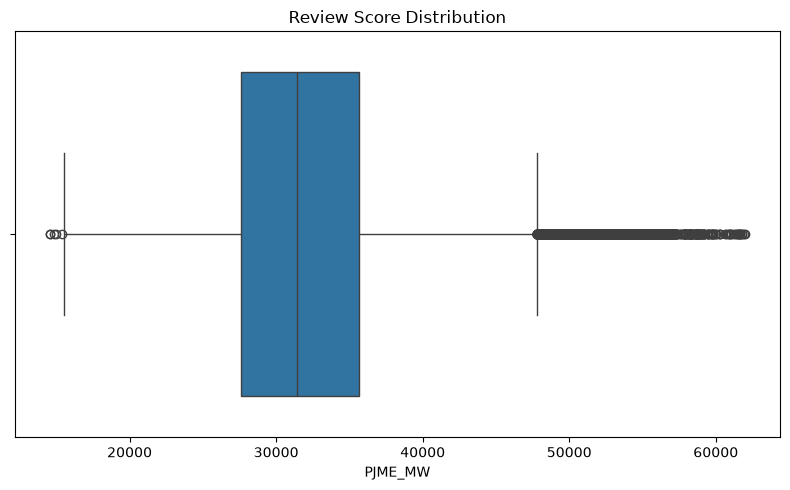

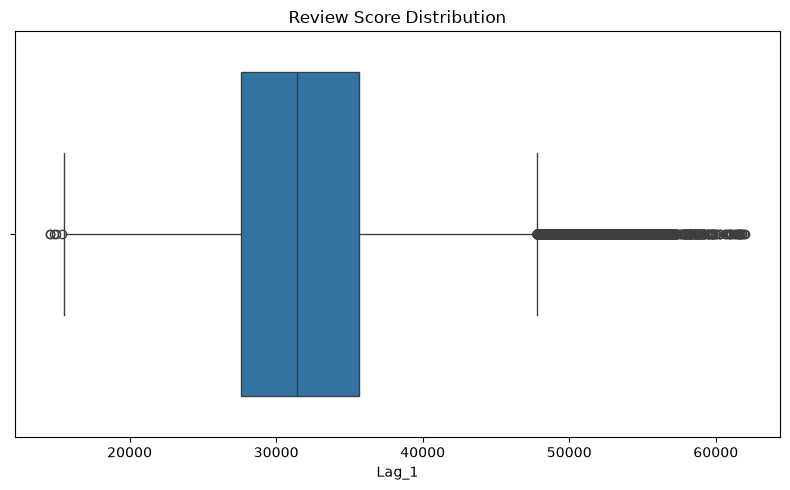

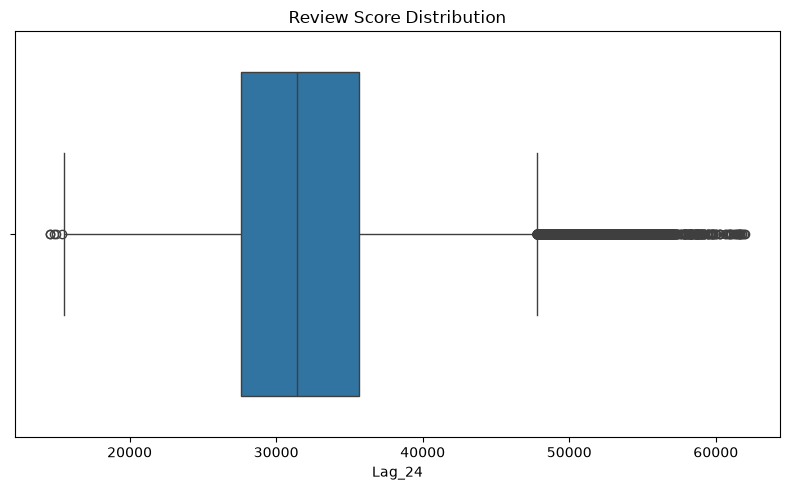

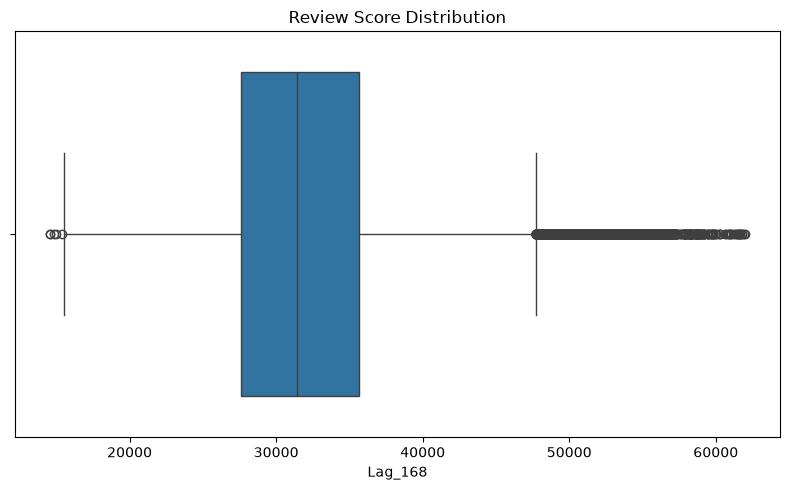

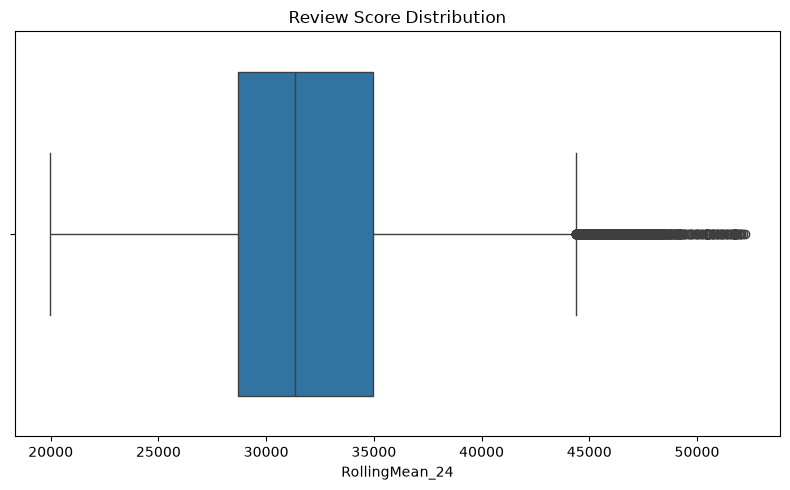

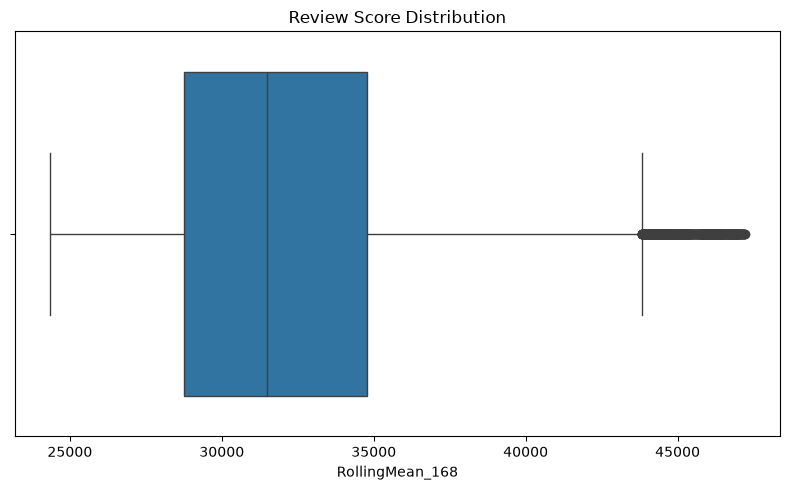

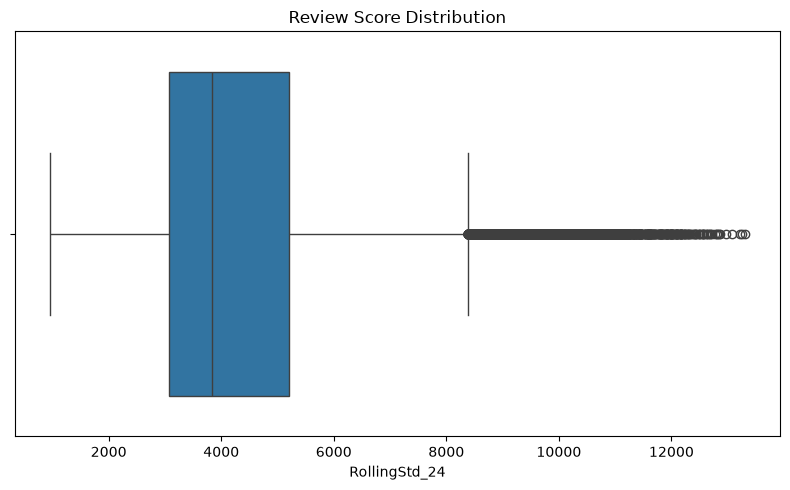

In [40]:
for column in numerical_column:

    plt.figure(figsize=(8,5))

    sns.boxplot( x=df[column])

    plt.title("Review Score Distribution")

    plt.tight_layout()

    plt.show()

In [43]:
df.to_csv("../Dataset/df_for_EDA.csv" , index=False)

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

In [48]:
for column in numerical_column:
    df[column] = scaler.fit_transform(df[[column]])

In [49]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-24 01:00:00,-0.752893,1,3,12,24,52,1998,0,-0.543034,-0.682179,-0.862604,-0.573754,-0.298410,-0.877455
1,1998-12-24 02:00:00,-0.995682,2,3,12,24,52,1998,0,-0.752884,-0.915251,-1.071797,-0.578516,-0.297664,-0.861416
2,1998-12-24 03:00:00,-1.109499,3,3,12,24,52,1998,0,-0.995674,-1.020264,-1.160523,-0.583801,-0.297164,-0.840452
3,1998-12-24 04:00:00,-1.138263,4,3,12,24,52,1998,0,-1.109491,-1.088005,-1.188549,-0.586774,-0.296670,-0.827981
4,1998-12-24 05:00:00,-1.072849,5,3,12,24,52,1998,0,-1.138255,-1.090325,-1.116237,-0.585728,-0.296243,-0.832156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,1.887011,3,6,3,2,9,2014,1,1.896151,2.119943,1.555123,1.819578,2.471139,-1.119759
145194,2014-03-02 04:00:00,1.804587,4,6,3,2,9,2014,1,1.887027,2.030550,1.351504,1.806200,2.475581,-1.184604
145195,2014-03-02 05:00:00,1.595974,5,6,3,2,9,2014,1,1.804602,1.791446,1.045223,1.794629,2.480970,-1.223618
145196,2014-03-02 06:00:00,1.249884,6,6,3,2,9,2014,1,1.595989,1.469445,0.653160,1.781628,2.486800,-1.234458
